# ===== Coffee Co. Dataset Preprocessing =====
This notebook houses the preprocessing steps for each of the three datasets we will be using for our final master dataset; which consists of merging each dataset together. The notebook is broken down into 3 parts. Each part represents the same preprocessing steps carried out on the individual datasets. Chosing not to preprocess the data from each source together produced a longer and more repetitive codebase. However the benifits were improved readability and ensure each dataset recieved a meticulous and tailored approach. 

### **Notebook Contents**
 - 0.1      - Imports and Initilisations 
 - 1.1 - 1. - Preprocessing stages for **dataset one**.
 - 2.1 - 2. - Preprocessing stages for **dataset two**.
 - 3.1 - 3. - Preprocessing stages for **dataset three**
 - 4.1 - 4. - Mergeing  the datasets together forming the **Master Dataset**

### **Preprocessing steps are as follows:** 

1. **Perform dataset inspection** - Gathering information from shape, dtypes, nulls and duplicates. This helps in building a top level understanding of the dataset. 

2. **If there are nulls and duplicates present** - Handle them by removing the observation completely or re-write specific values via imputation. 

3. **Amend data types** - In order for the dataset to be compatabile with specific models, certain dataypes must be used. 

4. **Insepct and handle outliers or invalid values** - This stage involves determining whether or not there are any value present within the dataset that can be classified as unhelpful when deploying a model on the data (An example of this would be a negitive price or quantity amount).

5. **Standardise formats** - Organising aspects of the dataset like consistent casing and whitespace trimming. This ensures dataset robustness.

6. **Validate** - Performing a final check of shape, pulling a sample and confirming ratios will help to validate if the preprocessing steps have been successful. 

Order of operations:

Clean df1 and df2 separately (dtypes, cancellations, dates) — where you are now
Merge df1 + df2 → combined (transaction-level, deduped)
Enrich combined with synthetic store-context columns inspired by df3's schema (store_type, weather, payment_method) — still transaction-level
Build customer_features table from the enriched combined — groupby Customer ID, one row per customer
Boxplot + outlier check on customer_features
StandardScaler on customer_features
Feed into SDV to generate your final synthetic dataset (learns from real customer-level patterns)
K-Means vs DBSCAN on the SDV output

What gets fed into SDV is it the customer level table or the master dataset itself? Im viewing master and customer_level as two separate tables, despite customer_level builds from master?Reconciling customer-level aggregation versus transaction-level data inputsReconciling customer-level aggregation versus transaction-level data inputsCustomer-level table — that's what SDV should learn from and generate synthetic rows of, since your clustering unit is "customer," not "transaction."
Master dataset (combined) stays as your real data source. customer_features is derived from it and is what SDV uses to generate new, synthetic customers with realistic behavioural patterns (spend, frequency, cancellation rate, etc.) at the same granularity.


## 0.0 Package Imports
To keep the notebook clean, we will ensure that all imports are kept within the same code block at the top. 

In [318]:
#Imports:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

## 1.0 Import dataset's and initilise a dataframe's
This code block represents where our datasets are imported and initilised. Copies of the raw datasets are created within this code block. This is done in order to ensure the original datasets are preserved and unchanged. 

In [319]:
#Import the first dataset:
dataset1 = pd.read_csv("../raw_data/Online_retail_One.csv", skiprows =1)
#Import the second dataset:
dataset2 = pd.read_csv("../raw_data/Online_retail_Two.csv", skiprows =1)
#Import the final dataset:
dataset3 = pd.read_csv("../raw_data/Consumer_Meta.csv", skiprows =1)


#Create a copy of each dataset in order to preseve to original:
df1 = dataset1.copy()
df2 = dataset2.copy()
df3 = dataset3.copy()

## 1.1 - Perform Top-Level dataset inspection
Here, we will begin to build an understanding of the overall look and behaviour of the first two datasets. df1 and df2 both originate from the same source. They are datasets for a retail store spanning different years ([df1 = 2009-2010] & [df2 = 2010 - 2011]). This is highly benifitcal as repeat customers are recorded under the same schema across hundereds of thousands of observations.  

### 1.1.1 Dataset Shape

In [320]:
# Print out the shape of the first dataset: 
print("Dataset One Shape:", df1.shape)
# Print the shape of the second dataset:
print("Dataset Two Shape:", df2.shape)

Dataset One Shape: (525461, 8)
Dataset Two Shape: (541910, 8)


The above code block informs us that we are working with a dataset with over 500,000 observations across 8 different features. Below we will implement a function that produces a summary health report for futher investigationary analysis. 

The results seen above gives us a brief overview of the data we are working with. Dataset one has 525,461 observations across 8 features and dataset two has 541,910 observations across the same eight features. With the aim being to combine these two datasets, before preprocessing we have a dataset that will contain 1,067,371 observations.

### 1.1.2 Dataset Health Summary

In [321]:
# Initlise the function: 
def health_summary(df):
    report = pd.DataFrame({
        'Data Type  ': df.dtypes,
        'Null Values  ': df.isnull().sum(),
        'Unique Values  ': df.nunique(),
        'Duplicate Values   ': df.duplicated().sum()
    })
    return report

print("-----------     Dataset One Health Summary     ------------")
display(health_summary(df1))
print("")
print("-----------     Dataset One Health Summary     ------------")
display(health_summary(df2))

-----------     Dataset One Health Summary     ------------


,Data Type,Null Values,Unique Values,Duplicate Values
Invoice,str,0,28816,6865
StockCode,str,0,4632,6865
Description,str,2928,4681,6865
Quantity,int64,0,825,6865
InvoiceDate,str,0,25296,6865
Price,float64,0,1606,6865
Customer ID,float64,107927,4383,6865
Country,str,0,40,6865



-----------     Dataset One Health Summary     ------------


,Data Type,Null Values,Unique Values,Duplicate Values
Invoice,str,0,25900,5268
StockCode,str,0,4070,5268
Description,str,1454,4223,5268
Quantity,int64,0,722,5268
InvoiceDate,str,0,23260,5268
Price,float64,0,1630,5268
Customer ID,float64,135080,4372,5268
Country,str,0,38,5268


The health summary's outputs give an insight into the behaviour of the data that will need addressing before merging can be carried out. As previously mentioned, one of the biggest benifits to these two datasets is that they are sourced from the same location. This means the data is already highly compatible. Whatever steps need to be carried out for preprocessing will look very similar. 

Approaching the health summary in order, the first issue that will need addressing is converting non numerical data types to numerical ones to ensure compatibility with the models deployed within the machine learning pipeline. Following this is addressing null values. Finally, duplicate values will also neeed to be addressed. Duplicates will need to be meticulously dealt with in order not to remove any important data. Cross referencing the dates in which the datasets each cover will also be critical in ensuring there is no overlap between the datasets - as this is not currently displayed withn this table. 

## 1.2 - Handiling Null values
As mentioned, the first step that needs carrying out for preprocessing is handiling null values across both datasets. In both instances, there is only two feature's that contain null values: 

 1. **Dataset One**

    - **Description** [2928 Missing Values]
    - **Customer ID** [107927 Missing Values]
 2. **Dataset Two**

    - **Description** [1454 Missing Values]
    - **Customer ID** [135080 Missing Values]

3. **Combined Null Values**
     - Description [4382 Missing Values]
     - Customer ID [243007 Missing Values]

The sum of null values within the data equaites to 22.77 - 23.18% of the total observations; depending on the overlap between the two features. Considering the extensive range of observations within the dataset, the best course of action would be to remove all instances of null observations. Removed all occurances would still leave between 824,364 - 819,982 observations within the dataset, still providing a comprehensive dataset. 

In [322]:
# Removing all null values from dataset: 
df1 = df1.dropna()
df2 = df2.dropna()

# Implement a check to seee if the null values were correctly dropped:
def nullValidation(df1, df2):
    if (df1.isnull().sum().sum() == 0, df2.isnull().sum().sum()):
        return "All null values were successfully removed from both datasets"
    else:
        return "There was an error removing null values!"

print("")
print(nullValidation(df1, df2))


All null values were successfully removed from both datasets


## 1.3 - Amending Data Types
In anticipation of the models that will be used in the machine learning section, we need to convert all non-numerical datatypes found wihtin both datasets. Using K-means and DBSCAN means that all data needs to be converted to numericals as both models are distance based, meaning strings and categories can not be used.

Also found within the code block below is a data type format inspection. This is a simple print function that displays a single observation of specific elements. This is aim my deciscion in how I will approach changing the format of specific features when carrying out data type conversion. For example 'Invoice Date'. For something like a date, choosing the correct strategy to split the date up into can be impactful on the final model. 

### 1.3.1 - Datatype Table Overview

In [323]:
# Print an overview of the datatypes recorded for each category
print("-----------     Dataset One Data Types     ------------")
print("")
print(df1.dtypes)
print("")
print("-----------     Dataset Two Data Types     ------------")
print("")
print(df2.dtypes)

-----------     Dataset One Data Types     ------------

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object

-----------     Dataset Two Data Types     ------------

Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In order to aid my conversion strategy, it would be useful to insepct the formatting of each feature category. Understanding how values are formatted will help decide the best approach of splitting data as well as identifying features that are not needed. 

### 1.3.2 - Datatype Formatting Inspection

In [324]:
print("----   Dataset One Data Types Format Inspection   -----")
print("")
for column in df1.columns:
    print(column,":", df1[column].iloc[0])

print("")
print("----   Dataset One Data Types Format Inspection   -----")
print("")
for column in df2.columns:
    print(column,":", df2[column].iloc[0])

----   Dataset One Data Types Format Inspection   -----

Invoice : 489434
StockCode : 85048
Description : 15CM CHRISTMAS GLASS BALL 20 LIGHTS
Quantity : 12
InvoiceDate : 12/1/09 7:45
Price : 6.95
Customer ID : 13085.0
Country : United Kingdom

----   Dataset One Data Types Format Inspection   -----

Invoice : 536365
StockCode : 85123A
Description : WHITE HANGING HEART T-LIGHT HOLDER
Quantity : 6
InvoiceDate : 12/1/10 8:26
Price : 2.55
Customer ID : 17850.0
Country : United Kingdom


The results in the above two code blocks hightlight that five out of 8 categories are in need of data type conversions or removal. The approach for this section will be to work our way down eahc feature in the order they appear in the list: 

-  **'Invoice'** - This feature is currently a string, but as seen above, a typical observation shows that a value is a string of integers. This gives away a key hint that there may be non-numerical values hidden in certain observation. This will need inspecting before converting to a numerical datatype, in order to avoid errors. 

- **'Stock Code'** - 

- **'Description'** - Description is the first feature that we come across that can be dropped from the dataset. This is due to how the feature provides no depth for the model to draw meaningful connections from consumer behaviour. 

- **'Quantity'** - 

- **'InvoiceDate'** - 

- **'Price'** - 

- **'Customer ID'** - 

- **'Country'** - This can be dropped as it provides no relevance for consumer behavoir as well as not fitting in with the context of our hypothetical coffee shop as it is not international. This category can be dropped. 

- 'Invoice' & 'StockCode' - As these features are strings, but a typical example of an observation shows only integers, it tells us that there may be a case of char's being used to denote particular behaviour (such as a cancellelation) within the data. This will need to be checked before changing these features to integer types. 

### 1.3.3 - 'Invoice' Feature Inspection and Conversion

In [325]:
# Check invoice for non-numerical values:
dataset1_outliers = df1[df1['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()
dataset2_outliers = df2[df2['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()

print("")
print("----     Dataset Invoice Outliers Check     -----")
print("")
print("The number of outlier values in dataset one is:", len(dataset1_outliers))
print("The number of outlier values in dataset two is:", len(dataset2_outliers))
print("The sum of outlier values in both dataset's is:", len(dataset1_outliers) + len(dataset2_outliers))
print("")

# If an outlier is present, print an example:
if len(dataset1_outliers) > 0:
    print("Example of an Invoice Outlier (df1):",dataset1_outliers[0])
elif len(dataset2_outliers) > 0:
    print("Example of an Invoice Outlier (df2):",dataset2_outliers[0])
else:
    print("No outliers found")

print("")
# Identify all cases where a non-numrical character is present. 
non_numeric_invoice = df1[df1['Invoice'].astype(str).str.contains(r'[^0-9]', regex = True)]['Invoice']
# Extract all cases of non-numerical characters.
invoice_unique_prefixes = non_numeric_invoice.str.extract(r'([^0-9]+)')[0].unique()
# Print the list of different non-numerical characters found within 'Invoice'
print("List of outlier characters in Invoice:")
print(invoice_unique_prefixes)


----     Dataset Invoice Outliers Check     -----

The number of outlier values in dataset one is: 4372
The number of outlier values in dataset two is: 3654
The sum of outlier values in both dataset's is: 8026

Example of an Invoice Outlier (df1): C489449

List of outlier characters in Invoice:
<StringArray>
['C']
Length: 1, dtype: str


Investigation analysis has confirmed that there are outliers present in both datasets. Printing a list of character variance displays that there is only one character present out of all observations. The character 'C' is not explained however, it would be reasonable to assume that linked with invoice 'C' would mean cancelled. As part of the next step, all outlier values will need to be removed before converting to an integer data type to avoid any errors. However, it would be benificial to save these results as their own feature as having data on which customers cancel or fail to pay is very valuable information in the context of building consumer profiles. 

Creating a new cancellation feature column also opens up the oppurtunity to calculate cancellation rate value for each consumer as well, further deepening the consumer profile.  

In [326]:
# Begin implementing the cancellations feature:

# Create a new column where each occurance of C wihtin Invoice is marked as either 0 or 1:
df1['order_cancelled'] = df1['Invoice'].astype(str).str.contains('C', case = False).astype(int)
df2['order_cancelled'] = df2['Invoice'].astype(str).str.contains('C', case = False).astype(int)

# Calculate cancellation rate per customer using newly formed cancellation data:
cancellation_rate = df1.groupby('Customer ID')['is_cancellation'].mean()


# Convert 'Invoice' from a string to an int in both datasets:
df1['Invoice'] = df1['Invoice'].astype(str).str.replace('C','', regex = False).astype(int)
df2['Invoice'] = df2['Invoice'].astype(str).str.replace('C','', regex = False).astype(int)

#Perform a confirmation check of removed characters: 
check1 = df1[df1['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()
check2 = df2[df2['Invoice'].astype(str).str.isnumeric() == False]['Invoice'].unique()

if len(check1) > 0:
    print("Outlier still present (df1):", len(check1), "remaining")
elif len(check2) > 0:
    print("Outlier still present (df2):", len(check2), "reamaining")
else:
    print("")
    print("No outliers found")

KeyError: 'Column not found: is_cancellation'

### 1.3.2 - StockCode feature inspection
StockCode is slightly different than Invoice. The stock code of a product does not specifically help with building consumer segmentation profiles, nor does it provide any deep context for a model to do this. We know that there are no null values in either dataset at this point as they have already been handled and duplicated will be dealt with further on. So 'StockCode' will be left as it is at this point.

StockCode also produced some interesting results. There was a total of 33 different characters that were found across all the values. This produced a question for me to think about - Do I completely remove each instance of an character being present within each product code. For this, I chose not to remove the characters. Instead, I opted to preseve the feature columns as it is. I made this decision for two reasons. The first is that if I start removing characters from an extensive list of products I may introduce new more complex problems (IE 3589A and 3589B would both become 3589). Secondly, I relaised that I do no need to use this column specifically within the model pipeline. Instead, I could use this feature and its observations to derive another column called 'Unique Products Bought' This feature would be calculated per customer and already be and integer datatype.

### 1.3.3 - Description feature inspection
The feature 'Description' also poses no beinift for our model. This feature can be removed completely from both datasets. 

In [ ]:
# Remove 'Description' from both datasets
df1 = df1.drop(['Description'], axis = 1, errors = 'ignore')
df2 = df2.drop(['Description'], axis = 1, errors = 'ignore')

### 1.3.4 - InvoiceDate feature inspection
The next column that need attention is 'InvoiceDate'. This is where understanding formatting is highly benificial. Removing the feature in its entirity would be removing useful information. Instead, the information contained within eahc value will be parsed into its own features, before finally removing the original feature column ('InvoiceDate') entirely. 

What will be kept from the original values is;

 - Day of the week
 - Hour of day
 - Month of the year

The rest of the data (Year and seconds) can be discard as they provide very little benifit for our model. 

In [ ]:
#Parse 'Invoive Date' into date time as first step:
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'], format = '%m/%d/%y %H:%M')
df2['InvoiceDate'] = pd.to_datetime(df2['InvoiceDate'], format = '%m/%d/%y %H:%M')

# Implement hour feature:
df1['hour'] = df1['InvoiceDate'].dt.hour
df2['hour'] = df2['InvoiceDate'].dt.hour

# Implement day of week feature:
df1['day_of_week'] = df1['InvoiceDate'].dt.dayofweek
df2['day_of_week'] = df2['InvoiceDate'].dt.dayofweek

# Implement month feature:
df1['month'] = df1['InvoiceDate'].dt.month
df2['month'] = df2['InvoiceDate'].dt.month

# Once encoding is completed, remove 'Invoice Date' feature:
df1 = df1.drop(['InvoiceDate'], axis = 1, errors = 'ignore')
df2 = df2.drop(['InvoiceDate'], axis = 1, errors = 'ignore')

### 1.3.5 - Customer ID feature inspection
'Customer ID' is a float data type. Whilst this is not necessarily an issue, it is a good idea to perfrom an inspection into the feature to introduce some robustness to the preprocessing pipeline. An indication as to why this feature might be a float is due to the amount of null values we idenified and removed in the the first part of preprocessing. Null or NaN values cannot be stored within an integer data type, which is the main reason a float would be assigned to this feature. 

In [ ]:
# Check for any non-interger values within Customer ID: 
def non_ints(df):
    # Compute the sum of all values not whole numbers:
    if len(df[df['Customer ID'] % 1 != 0]) == 0:
        return "No non-Integer values present"
    else:
        return "Non-Integer values present!"
    
print("Dataset One: ",non_ints(df1))
print("Dataset Two: ",non_ints(df2))

Dataset One:  No non-Integer values present
Dataset Two:  No non-Integer values present


Confirming there are no invalid values within Consumer ID means conversion from float to integer can be carried out successfully in the code block below. Along side the conversion, the oppurtinity to enrich my dataset even more was spotted. By combining unique stockcodes per customer, we are able to derive a value representing the range of indiviual products each customer buys. This is valuable as it highlights two key metrics. Either, a customer buys the same set of few products or they expand their purchasing habits to a wider range of products - displaying a likely hood to try new products. 

In [ ]:
# Convert 'Customer ID' from Float to Int: 
df1['Customer ID'] = df1['Customer ID'].astype(int)
df2['Customer ID'] = df2['Customer ID'].astype(int)

# Create the new feature column - 'unique_products-bought'
print("Example of how the new 'unique_products_bought' feature functions:")
unique_products_bought = df1.groupby('Customer ID')['StockCode'].nunique()
# Example of new 
print(unique_products_bought.head())

Example of how the new 'unique_products_bought' feature functions:
Customer ID
12346    29
12347    70
12348    20
12349    92
12351    21
Name: StockCode, dtype: int64


### 1.3.6 - Country Feature Inspection
Similarly to 'Description', 'Country' can also be dropped from both datasets. This is due to the context of international stores being irrelevant within this project scope. Our fictional coffee shop does not have locations opened internationally, only national/ regional. 

In [ ]:
# Drop 'Country' from both datasets: 
df1 = df1.drop(['Country'], axis = 1, errors = 'ignore')
df2 = df2.drop(['Country'], axis = 1, errors = 'ignore')

### 1.3.7 - Data type conversion confirmation
All the feature from both datasets have now been insepcted and the identified action has been taken to convert datatypes to conformitive ones. Before moving on to the next stage in the preprocessing steps, confirmation of feature datatypes will be carried out below. 

In [ ]:
# Print an overview of the datatypes recorded for each category
print("")
print("-----------     Dataset One Data Types     ------------")
print("")
print(df1.dtypes)
print("")
print("-----------     Dataset Two Data Types     ------------")
print("")
print(df2.dtypes)


-----------     Dataset One Data Types     ------------

Invoice              int64
StockCode              str
Quantity             int64
Price              float64
Customer ID          int64
is_cancellation      int64
hour                 int32
day_of_week          int32
month                int32
dtype: object

-----------     Dataset Two Data Types     ------------

Invoice              int64
StockCode              str
Quantity             int64
Price              float64
Customer ID          int64
is_cancellation      int64
hour                 int32
day_of_week          int32
month                int32
dtype: object


## 1.4 - Check for negative Quantity/Price (returns) and extreme outliers (bulk wholesale orders).
Further checks are carried out on the data. This section is revolved around building a pictue of the behaviour of the data and what it represents. For example examining the data for negative quantity or price values that could be used to represent cancelled sales or returned items. This information will then be used to determine what the correct action is to take. 

**Negative Quantitiies or Prices** - Negative prices and quantities are searched for within the data set. This search is carried out for two reasons. The first is to confirm whether the is_cancellation feature correctly pairs with invoices that are indicated to have been cnacelled or whether there is unflagged / cancellation errors that need sorting with te dataset. The second reason is determine if individual products are returned for the same invoice or if they are issued a sepaerate invoice per product, which would also cause issues due to inflatinf transaction record amounts. 

**Extreme Outliers** - Checks need to be carried out that identifies if there are any outliers present within the data. This is done as working with outliers can produce skewed reuslts, especially in the case of clustering algorithms. In some cases cluster centroids toward it and distort everyone else's grouping. 

### 4 - Negative quantity inspection
The below code block intorduces the first steps in building a picture of and negative values within quantity feature column. 

In [ ]:
# Print a summary of observations 
print("----------------------    Dataset one description    ----------------------")
display(df1[df1['Quantity'] < 0].head(20))
print("")
print("----------------------    Dataset two description    ----------------------")
display(df2[df2['Quantity'] < 0].head(20))

----------------------    Dataset one description    ----------------------


,Invoice,StockCode,Quantity,Price,Customer ID,is_cancellation,hour,day_of_week,month
178,489449,22087,-12,2.95,16321,1,10,1,12
179,489449,85206A,-6,1.65,16321,1,10,1,12
180,489449,21895,-4,4.25,16321,1,10,1,12
181,489449,21896,-6,2.10,16321,1,10,1,12
182,489449,22083,-12,2.95,16321,1,10,1,12
183,489449,21871,-12,1.25,16321,1,10,1,12
184,489449,84946,-12,1.25,16321,1,10,1,12
185,489449,84970S,-24,0.85,16321,1,10,1,12
186,489449,22090,-12,2.95,16321,1,10,1,12
196,489459,90200A,-3,4.25,17592,1,10,1,12



----------------------    Dataset two description    ----------------------


,Invoice,StockCode,Quantity,Price,Customer ID,is_cancellation,hour,day_of_week,month
141,536379,D,-1,27.50,14527,1,9,2,12
154,536383,35004C,-1,4.65,15311,1,9,2,12
235,536391,22556,-12,1.65,17548,1,10,2,12
236,536391,21984,-24,0.29,17548,1,10,2,12
237,536391,21983,-24,0.29,17548,1,10,2,12
238,536391,21980,-24,0.29,17548,1,10,2,12
239,536391,21484,-12,3.45,17548,1,10,2,12
240,536391,22557,-12,1.65,17548,1,10,2,12
241,536391,22553,-24,1.65,17548,1,10,2,12
937,536506,22960,-6,4.25,17897,1,12,2,12


From the results above we can clearly see two things. The first is that cancelled products are listed seperatly, but are assigned the same invoice value, showing they belong to the same transaction. Secondly, from this table it would also be reasonable to assume that all occurances of a cancellation do correspond to an is_cancellation value of 1. However as only the last 20 results are displayed, there should be caution taken around relying soley on these records that all other occurances of cancelled products also correspond to the correct is_cancelled value. As a result a further check of this will be carried out below. 

In [ ]:
# Check both datasets for any occurancances of cancellations and an incorrect is_cancellation value of 0:
def cancellation_record_check(df):
    # If quantity is a negative value and is_cancellation corresponds to a 0:
    if len(df[(df['Quantity'] < 0) & (df['is_cancellation'] == 0)]) != 0:
        return "Occurances of incorrect value(s) found in df1"
    else:
        return "There are no occurances of incorrect 'is_cancellation' values found"

print("")
print("df1: ",cancellation_record_check(df1))
print("df2: ",cancellation_record_check(df2))



df1:  There are no occurances of incorrect 'is_cancellation' values found
df2:  There are no occurances of incorrect 'is_cancellation' values found


The above code block confirms that there is no incorrect occurances of is_cancellation values found. Before moving on to inspecting the dataset for outliers, one last check for negative prices will be carried out. This is important as a negative price observation that is not caught may cause some distoration within specific features in the customer-level features table. If there are no negative values present, then we are able to move forward.  

In [ ]:
# Print the sum of all occurances where price is less than 0.
print("Negative Price:", (df1['Price'] < 0).sum())

# Implement a function that prints 
def negative_price(df):
    if len(df['Price'] < 0) < 0:
        display(df1[df1['Price'] < 0].head())

print("df1:", negative_price(df1))
print("df2:", negative_price(df2))

Negative Price: 0
df1: None
df2: None


### 4.2 - Dataset Outlier's Inspection

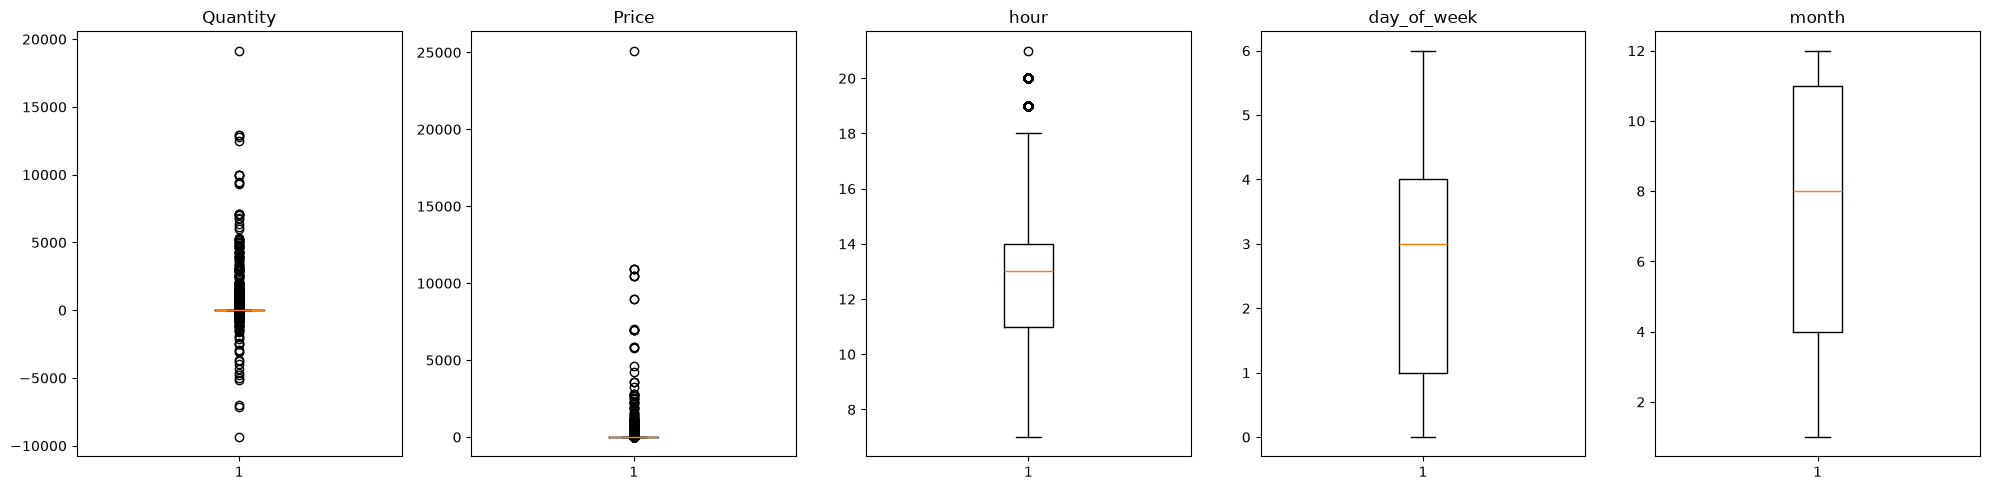

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
cols = ['Quantity', 'Price', 'hour', 'day_of_week', 'month']

for i, col in enumerate(cols):
    axs[i].boxplot(df1[col])
    axs[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
print("----------------------    Dataset one description    ----------------------")
display(df1[['Quantity', 'Price', 'hour', 'day_of_week', 'month']].describe())
print("")
print("----------------------    Dataset two description    ----------------------")
display(df2[['Quantity', 'Price', 'hour', 'day_of_week', 'month']].describe())


----------------------    Dataset one description    ----------------------


,Quantity,Price,hour,day_of_week,month
count,417534.000000,417534.000000,417534.000000,417534.000000,417534.000000
mean,12.758815,3.887547,12.882400,2.679899,7.399716
std,101.220424,71.131797,2.316916,1.971269,3.474624
min,-9360.000000,0.000000,7.000000,0.000000,1.000000
25%,2.000000,1.250000,11.000000,1.000000,4.000000
50%,4.000000,1.950000,13.000000,3.000000,8.000000
75%,12.000000,3.750000,14.000000,4.000000,11.000000
max,19152.000000,25111.090000,21.000000,6.000000,12.000000



----------------------    Dataset two description    ----------------------


,Quantity,Price,hour,day_of_week,month
count,406830.000000,406830.000000,406830.000000,406830.000000,406830.000000
mean,12.061276,3.460507,12.737470,2.606406,7.605958
std,248.693065,69.315080,2.284949,1.921906,3.418945
min,-80995.000000,0.000000,6.000000,0.000000,1.000000
25%,2.000000,1.250000,11.000000,1.000000,5.000000
50%,5.000000,1.950000,13.000000,2.000000,8.000000
75%,12.000000,3.750000,14.000000,4.000000,11.000000
max,80995.000000,38970.000000,20.000000,6.000000,12.000000


In [ ]:
df1.sort_values('Quantity', ascending=False).head(10)

,Invoice,StockCode,Quantity,Price,Customer ID,is_cancellation,hour,day_of_week,month
90857,497946,37410,19152,0.10,13902,0,11,0,2
127166,501534,21099,12960,0.10,13902,0,13,2,3
127168,501534,21091,12960,0.10,13902,0,13,2,3
127169,501534,21085,12744,0.10,13902,0,13,2,3
127167,501534,21092,12480,0.10,13902,0,13,2,3
135029,502269,21980,10000,0.25,17940,0,15,1,3
135027,502269,21984,10000,0.25,17940,0,15,1,3
135028,502269,21982,10000,0.25,17940,0,15,1,3
135030,502269,21981,10000,0.25,17940,0,15,1,3
93677,498152,85220,9456,0.30,13902,0,10,2,2


In [ ]:
#customer_features['avg_order_size'] = df1.groupby('Customer ID')['Quantity'].mean()

NameError: name 'customer_features' is not defined